In [1]:
import eelbrain as eel
import mne
import numpy as np
import matplotlib.pyplot as plt
import json
import pandas as pd
import pathlib

In [2]:
def src_to_mesh(src):
    rr = src['rr']
    tris = src['tris']

    # some versions provide 'tris' only for in-use verts
    if 'use_tris' in src:  
        inuse = src['inuse'].astype(bool)
        if inuse.any():
            # build remapping
            mapping = -np.ones(len(inuse), dtype=int)
            mapping[np.where(inuse)[0]] = np.arange(np.sum(inuse))

            rr = rr[inuse]
            tris = mapping[src['use_tris']]
            tris = tris[np.all(tris >= 0, axis=1)]

    return rr, tris

def saturate_M(M, K):
    return (K * M) / (M + K)

def save_J_stats_to_json(filepath, M=None, morph=None, maxnorm=False):
    fp = pathlib.Path(filepath)
    adj = pd.read_csv(fp).iloc[:, 1:].values.T

    for sign in ['positive', 'negative']:
        if sign == 'negative':
            adj_thresh = -(adj * (adj < 0))
        else:
            adj_thresh = (adj * (adj > 0))
            
        if not morph is None:
            assert(isinstance(morph, str))
            anat_raw = pd.read_csv(morph).iloc[:, 1:].values
            anat = anat_raw.T/anat_raw.T.sum(axis=1)[:, np.newaxis]
            adj_thresh = anat@adj_thresh@anat.T
    
        areanormed = ""
        if not M is None:
            areanormed="_areanormed"
            adj_thresh /= M
            
        maxnormed = ""
        if maxnorm:
            maxnormed = "_maxnormed"
            if adj_thresh.max() != 0:
                adj_thresh = adj_thresh/adj_thresh.max()
            else:
                adj_thresh = np.zeros_like(adj_thresh)
            
        print(fp, sign)
        plt.imshow(adj_thresh, vmax=1)
        plt.show()
        
        # 4th power is often useful for
        with open(f'../statmaps/adjacency_{fp.name}_{sign}{areanormed}{maxnormed}_quad.json', 'w') as f:
            json.dump({"J":(adj_thresh**4).astype(float).tolist()}, f)
        
        with open(f'../statmaps/adjacency_{fp.name}_{sign}{areanormed}{maxnormed}_raw.json', 'w') as f:
            json.dump({"J":(adj_thresh).astype(float).tolist()}, f)
            
            
def create_region_mesh(regions, hemi, save=True, suffix=None, subject='fsaverage', subjects_dir="../mri"):
    if isinstance(regions, str):
        regions = [regions]
        
    if suffix is None:
        suffix = ""
        for roi in regions:
            suffix += f"_{roi}"
        
    outputs = []
    labs = None
    for region in regions:
        lab = mne.read_labels_from_annot(subject=subject,
                                   parc='aparc',
                                   hemi=hemi,
                                   regexp=region,
                                   subjects_dir=subjects_dir)
        if labs is None:
            labs = lab[0]
        else:
            labs += lab[0]
        
    if hemi == 'rh':
        hemiidx = 1
    else:
        hemiidx = 0
    inuse = src_origin[hemiidx]['inuse']
    mapping = -np.ones(len(inuse), dtype=int)
    mapping[np.where(inuse)[0]] = np.arange(np.sum(inuse))

    subregionverts = np.intersect1d(np.where(src_origin[hemiidx]['inuse'])[0], labs.vertices)
    subregionverts = np.array([mapping[i] for i in subregionverts]).astype(int)
    if hemi == 'rh':
        subregionverts += len(rr_lh_origin)
    subregiontris = np.array([list(i) for i in tris if np.all(np.in1d(i, subregionverts))]).astype(int)

    if save:
        with open(f'../meshes/{subject}_brainmesh_{hemi}{suffix}.json', 'w') as f:
            json.dump({"verts":origin_verts.tolist(), "tris":subregiontris.tolist()}, f)
        return
    else:
        outputs.append({"verts":origin_verts.tolist(), "tris":subregiontris.tolist(), "subregionverts":subregionverts.tolist()})
    
    return outputs

In [3]:
###### create brain meshes
subject = "fsaverage"
src_origin = mne.read_source_spaces(f"../mri/{subject}/bem/{subject}-ico-4-src.fif")
src_target = mne.read_source_spaces(f"../mri/{subject}/bem/{subject}-ico-1-src.fif")


###### ico-4
rr_lh, tris_lh = src_to_mesh(src_origin[0])
rr_rh, tris_rh = src_to_mesh(src_origin[1])

tris_rh += len(rr_lh)  # shift indices for RH
origin_verts = np.vstack([rr_lh, rr_rh])
tris = np.vstack([tris_lh, tris_rh])
rr_lh_origin = rr_lh


###### ico-1
rr_lh, tris_lh = src_to_mesh(src_target[0])
rr_rh, tris_rh = src_to_mesh(src_target[1])

tris_rh += len(rr_lh)  # shift indices for RH
target_verts = np.vstack([rr_lh, rr_rh])


###### cortex mesh
with open(f'../meshes/brainmesh{subject}.json', 'w') as f:
    json.dump({"verts":origin_verts.tolist(), "tris":tris.tolist()}, f)
    
    
###### vertex locations
with open(f'../statmaps/vertices{subject}.json', 'w') as f:
    json.dump({"verts":target_verts.tolist()}, f)

anat_raw = pd.read_csv("../transforms/fs_anat_morph_32reg.csv").iloc[:, 1:].values
anat = anat_raw.T/anat_raw.T.sum(axis=1)[:, np.newaxis]
roi_target_verts = anat@target_verts
    
with open(f'../statmaps/vertices{subject}_32reg.json', 'w') as f:
    json.dump({"verts":roi_target_verts.tolist()}, f)
    
    
###### specific rois for highlighting
create_region_mesh(['parsopercularis', 'parstriangularis', 'parsorbitalis', 'insula'], 
                   'rh', suffix="_IF")

create_region_mesh(["precentral", "postcentral", "paracentral"], 
                   'rh', suffix="_SMC")

create_region_mesh(['inferiorparietal', "supramarginal"], 
                   'rh', suffix="_IP")

create_region_mesh(['superiortemporal', 'transversetemporal', 'middletemporal', "bankssts"], 
                   'rh', suffix="_T")

create_region_mesh(["caudalanteriorcingulate", "rostralanteriorcingulate"], 
                   'rh', suffix="_CING")

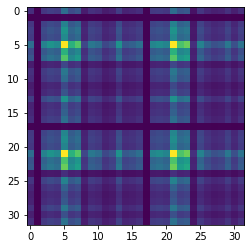

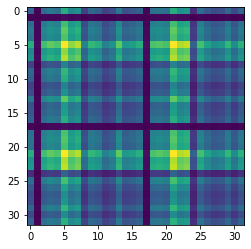

In [4]:
# create two region-area normalization maps
# usage: J_norm = J/M or J_norm = J/M_sat

anat_raw = pd.read_csv("../transforms/fs_anat_morph_32reg.csv").iloc[:, 1:].values

M = anat_raw.sum(axis=0)[:, np.newaxis] @ anat_raw.sum(axis=0)[np.newaxis, :]
K = 20.0
M_sat = saturate_M(M, K)
plt.imshow(M)
plt.show()
plt.imshow(M_sat)

In [5]:
J = pd.read_csv("/Users/vrishabcommuri/Downloads/theta_matrices/[R2519]-[visit=pre]-[session=EO1]-[trial=0]-[theta]-[fullmodel]_J.csv")
J.to_csv("../statmaps/sample_J_stats.csv")

../statmaps/sample_J_stats.csv positive


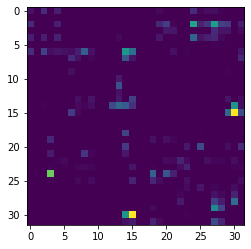

../statmaps/sample_J_stats.csv negative


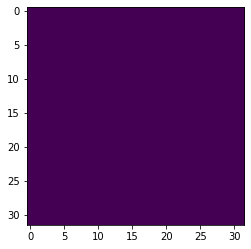

In [6]:
save_J_stats_to_json("../statmaps/sample_J_stats.csv", 
                     M=M_sat,
                     morph="../transforms/fs_anat_morph_32reg.csv", 
                     maxnorm=True)